# 02.5 — Stationarity Diagnostics & Autocorrelation Structure

## 1. Mục tiêu
Thực hiện kiểm định tính dừng (Stationarity Testing), chẩn đoán tự tương quan (ACF/PACF) và đưa ra cấu hình SARIMA đề xuất ban đầu:

1. **Kiểm định Tính dừng Kép (Dual Hypothesis Testing)**:
   - **ADF (Augmented Dickey-Fuller)**:
     - $H_0$: Chuỗi có nghiệm đơn vị (Non-stationary).
     - $H_1$: Chuỗi dừng (Stationary).
   - **KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**:
     - $H_0$: Chuỗi dừng quanh mức hằng số (Level stationary).
     - $H_1$: Chuỗi không dừng.
   - Cả hai kiểm định đều dùng tham số `regression='c'` (constant only, không giả định xu thế tuyến tính ngẫu nhiên cho lượng mưa).
2. **Chẩn đoán Hàm Tự Tương quan (ACF) & Tự Tương quan Riêng phần (PACF)**:
   - Xác định độ trễ tắt dần hay ngắt dứt điểm để định hướng tham số $p, q$.
   - Kiểm tra các vạch trễ tuần ($s=7$), tháng ($s=30$) và năm ($s=365$).
3. **Chẩn đoán Phần dư MSTL (MSTL Residual Diagnostics)**:
   - Kiểm tra xem phần dư sau khi phân rã có hội tụ về nhiễu trắng (White Noise) hay không.
4. **Lưu ý Khoa học về Cấu hình SARIMA Gợi ý**:
   $$\boxed{(p, d, q)(P, D, Q)_s = \text{EDA-suggested configuration}}$$
   - Đây chỉ là cấu hình gợi ý ban đầu dựa trên hình thái ACF/PACF để làm mốc so sánh, **không phải optimal configuration**. Cấu hình tối ưu sẽ được tìm kiếm qua GridSearch / Rolling-origin CV trong giai đoạn Modeling.
5. **Xuất Artifact**: `eda/outputs/stationarity_report.json`.


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Path resolution
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader, time_series_split
from src.eda.TemporalAnalysis import TemporalStructureAnalyzer
from src.eda.Stationarity import StationarityAutocorrelationAnalyzer

# 1. Nạp dữ liệu Train (Zero Leakage)
df = DataLoader().load_data()
train_df, _ = time_series_split(df)
print(f"📊 Kiểm định Tính dừng & Tự tương quan (Train Set: {len(train_df):,} ngày)")

# 2. Tạo phần dư MSTL độc lập (không phụ thuộc kernel khác)
temp_analyzer = TemporalStructureAnalyzer(train_df, target_col='Lượng mưa', date_col='Ngày')
mstl_res = temp_analyzer.decompose_mstl(periods=[7, 30, 365])

# 3. Khởi tạo StationarityAutocorrelationAnalyzer
stat_analyzer = StationarityAutocorrelationAnalyzer(
    train_df,
    target_col='Lượng mưa',
    date_col='Ngày',
    mstl_results=mstl_res,
    representative_periods=[7, 30, 122, 365]
)
stat_results = stat_analyzer.analyze()

# 4. Trích xuất kết quả kiểm định
stat_diag = stat_results.get('stationarity', {})
adf_res = stat_diag.get('adf_test', {})
kpss_res = stat_diag.get('kpss_test', {})

print(f"\n📉 KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG:")
print(f"   • ADF Statistic:  {adf_res.get('statistic', np.nan):.4f} (p-value: {adf_res.get('pvalue', np.nan):.4e})")
print(f"   • KPSS Statistic: {kpss_res.get('statistic', np.nan):.4f} (p-value: {kpss_res.get('pvalue', np.nan):.4f})")
print(f"   • Kết luận kết hợp: {stat_results.get('synthesis', {}).get('stationarity_conclusion', 'Trend/Difference stationary')}")

# Cấu hình gợi ý ban đầu
sarima_sug = stat_results.get('synthesis', {}).get('sarima_suggestions', {})
orders = sarima_sug.get('orders', [])
seasonal_orders = sarima_sug.get('seasonal_orders', [])
suggested_order = orders[0].get('order', (3, 0, 3)) if orders else (3, 0, 3)
suggested_seasonal = seasonal_orders[0].get('order', (1, 1, 1, 7)) if seasonal_orders else (1, 1, 1, 7)

print(f"\n💡 EDA-SUGGESTED SARIMA CONFIGURATION (Initial Baseline):")
print(f"   • Order (p, d, q):          {suggested_order}")
print(f"   • Seasonal Order (P, D, Q)_s: {suggested_seasonal}")


📊 Kiểm định Tính dừng & Tự tương quan (Train Set: 7,060 ngày)
📊 MSTL Decomposition
   - Periods: [7, 30, 365]
   - Windows: None
   - Lambda: None
   - Iterations: 2
   - STL kwargs: {}
   🔄 Applying log1p transformation (lmbda=None)
   ✅ MSTL decomposition completed successfully
   📊 Transform method: log1p
   📊 Components extracted: trend, seasonal, residual
   📤 Residual component available for Stationarity analysis
   🎯 Theory-Driven Parameters Extracted:
      • Representative periods: [7, 30, 122, 365]
      • Max lags recommended: 200
      • Seasonal periods: [7, 30, 122, 365]
      • Parameter source: theory_driven

🔍 PHẦN 3: THEORY-DRIVEN STATIONARITY & AUTOCORRELATION DIAGNOSTICS
🎯 Mục tiêu: Theory-driven chẩn đoán với representative periods

🔍 BƯỚC 1: CHẨN ĐOÁN TÍNH DỪNG
   📊 ADF Test:
      - Statistic: -8.604454
      - P-value: 0.000000
      - Result: ✅ Stationary
   📊 KPSS Test:
      - Statistic: 0.116789
      - P-value: 0.100000
      - Result: ✅ Stationary
   🎯 Kết

🎨 Trực quan hóa Tính dừng & Tự tương quan:


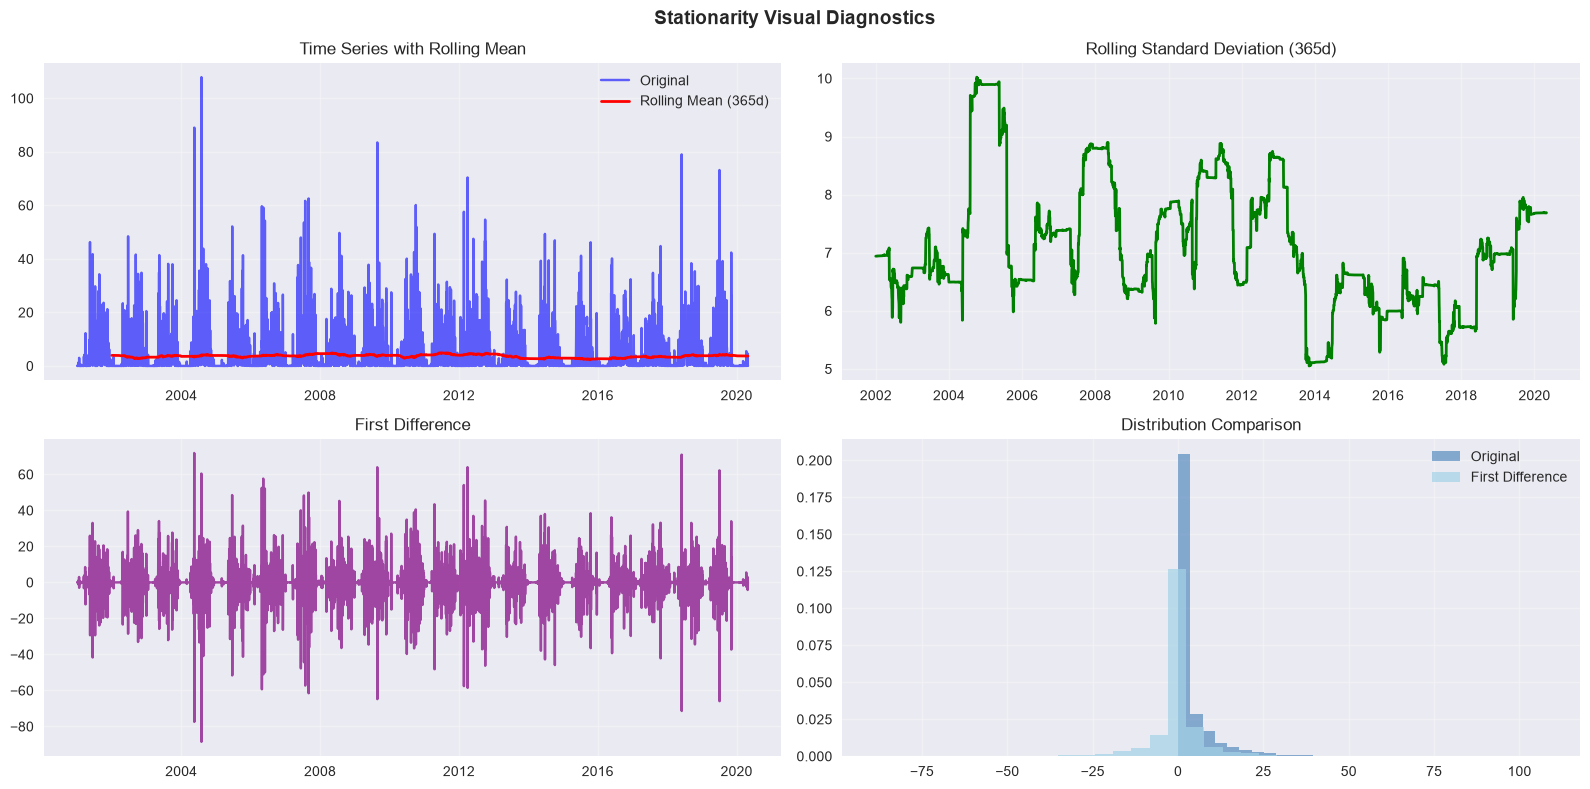

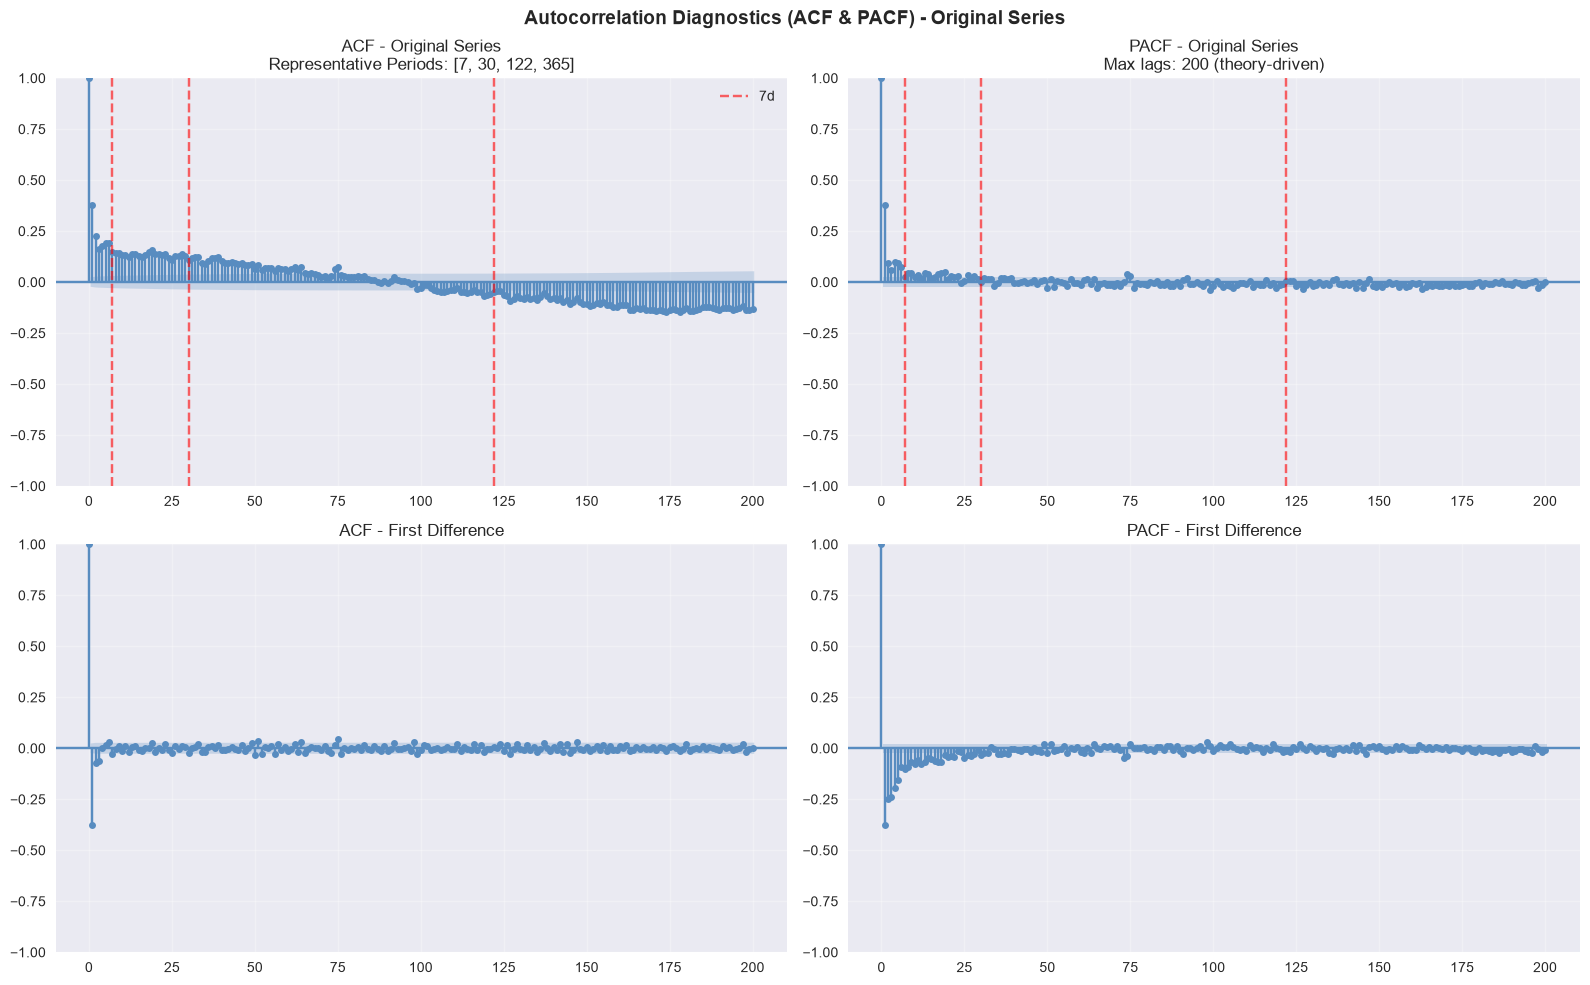

In [2]:
# 5. Trực quan hóa Rolling Statistics & Biểu đồ ACF / PACF
print("🎨 Trực quan hóa Tính dừng & Tự tương quan:")

# Panel 1: Rolling mean/std and differenced series
fig_stat = stat_analyzer.plot_stationarity_diagnostics(return_fig=True)
plt.show()

# Panel 2: ACF & PACF plot với các vạch chu kỳ lý thuyết
fig_acf = stat_analyzer.plot_autocorrelation(return_fig=True)
plt.show()


In [3]:
# 6. Xuất Artifact stationarity_report.json
OUTPUT_DIR = ROOT_DIR / "notebooks" / "eda" / "outputs"
DATA_OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "eda_outputs"

stat_artifact = {
    "adf_test": {
        "statistic": round(float(adf_res.get('statistic', 0)), 4),
        "pvalue": float(adf_res.get('pvalue', 0)),
        "is_stationary": bool(adf_res.get('is_stationary', True)),
        "regression": "c"
    },
    "kpss_test": {
        "statistic": round(float(kpss_res.get('statistic', 0)), 4),
        "pvalue": float(kpss_res.get('pvalue', 0)),
        "is_stationary": bool(kpss_res.get('is_stationary', False)),
        "regression": "c"
    },
    "configuration_status": "EDA-suggested configuration (NOT optimal configuration)",
    "suggested_sarima_order": list(suggested_order),
    "suggested_seasonal_order": list(suggested_seasonal),
    "differencing_d": 0 if adf_res.get('is_stationary', True) else 1,
    "representative_seasonal_period_s": 7
}

artifact_path = OUTPUT_DIR / "stationarity_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(stat_artifact, f, indent=2, ensure_ascii=False)

with open(DATA_OUTPUT_DIR / "stationarity_report.json", "w", encoding="utf-8") as f:
    json.dump(stat_artifact, f, indent=2, ensure_ascii=False)

print(f"\n💾 Stationarity report exported to: {artifact_path}")
print(f"   • Gợi ý SARIMA order: {stat_artifact['suggested_sarima_order']}")
print(f"   • Gợi ý Seasonal order: {stat_artifact['suggested_seasonal_order']}")



💾 Stationarity report exported to: D:\DS108_project\notebooks\eda\outputs\stationarity_report.json
   • Gợi ý SARIMA order: [3, 0, 3]
   • Gợi ý Seasonal order: [1, 1, 1, 7]
